# 02 - Log Parsing & Pattern Extraction

Notebook này gom log JSONL thành pattern/template, tính error-rate theo 30 phút, và dựng timeline incident để trả lời câu hỏi WHERE.

In [2]:
from pathlib import Path
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

BASE = Path(r'D:\\AWS\\AIOPS-study\\g2-data\\g2\\logs')
ART = Path(r'D:\\AWS\\AIOPS\\w1\\lab\\artifacts')
ART.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8')
ALERT_TIME = pd.Timestamp('2026-06-01T23:04:00Z')
from IPython.display import display


In [3]:
def normalize(msg: str) -> str:
    msg = re.sub(r'\b[0-9a-f]{16,}\b', '<hex>', msg, flags=re.I)
    msg = re.sub(r'\bORD-[A-Z0-9]+\b', 'ORD-<id>', msg)
    msg = re.sub(r'\b\d+\.\d+\b', '<num>', msg)
    msg = re.sub(r'\b\d+\b', '<num>', msg)
    return msg

def load_log(path: Path):
    rows = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            rec = json.loads(line)
            rec['timestamp'] = pd.to_datetime(rec['timestamp'], utc=True)
            rec['template'] = normalize(rec['message'])
            rows.append(rec)
    return pd.DataFrame(rows)

cart = load_log(BASE / 'cart-service.log.jsonl')
order = load_log(BASE / 'order-service.log.jsonl')
cart.head()

,timestamp,level,service,pod,trace_id,message,duration_ms,template,cache_size_mb,heap_used_mb,memory_limit_bytes,retry_count
0,2026-06-01 00:00:03.001000+00:00,INFO,cart-service,cart-service-7d9f8b-xaji0,a78dbc5073bfe4db,Item added to cart for userId=97782,16.0,Item added to cart for userId=<num>,NaN,NaN,NaN,NaN
1,2026-06-01 00:00:20.178000+00:00,INFO,cart-service,cart-service-7d9f8b-thv3a,a35ce1da1750210e,Item added to cart for userId=74081,8.0,Item added to cart for userId=<num>,NaN,NaN,NaN,NaN
2,2026-06-01 00:00:24.064000+00:00,INFO,cart-service,cart-service-7d9f8b-hsahx,fcaeebcddba6bccb,DB query executed table=cart rows=474,21.0,DB query executed table=cart rows=<num>,NaN,NaN,NaN,NaN
3,2026-06-01 00:00:30.800000+00:00,INFO,cart-service,cart-service-7d9f8b-thv3a,f28fe6d924bcb1ea,Checkout completed orderId=ORD-67284058,146.0,Checkout completed orderId=ORD-<id>,NaN,NaN,NaN,NaN
4,2026-06-01 00:00:38.378000+00:00,INFO,cart-service,cart-service-7d9f8b-y6dpb,acfa4e629d2c8b3f,DB query executed table=cart rows=322,11.0,DB query executed table=cart rows=<num>,NaN,NaN,NaN,NaN


In [5]:
cart_counter = Counter(cart['template'])
order_counter = Counter(order['template'])
pd.DataFrame(cart_counter.most_common(20), columns=['template', 'count']).to_csv(ART / 'cart_templates_top20.csv', index=False)
pd.DataFrame(order_counter.most_common(20), columns=['template', 'count']).to_csv(ART / 'order_templates_top20.csv', index=False)
pd.DataFrame(cart_counter.most_common(10), columns=['template', 'count'])

,template,count
0,Health check passed,3213
1,Item added to cart for userId=<num>,3086
2,DB query executed table=cart rows=<num>,2821
3,ProductCatalogCache eviction failed: heap pres...,2655
4,Checkout completed orderId=ORD-<id>,2021
5,ProductCatalogCache loaded <num> entries,1836
6,Connection pool nearing limit pool=db connecti...,1173
7,OutOfMemoryError imminent: available heap < <n...,944
8,Container OOMKilled: memory limit exceeded,819
9,Cache warm-up slower than expected startup_ms=...,710


In [6]:
cart['window_30m'] = cart['timestamp'].dt.floor('30min')
cart['is_warn_error'] = cart['level'].isin(['WARN', 'ERROR', 'FATAL'])
cart_window = cart.groupby('window_30m')['is_warn_error'].sum().reset_index(name='warn_error_count')
baseline = cart_window[(cart_window['window_30m'] >= pd.Timestamp('2026-06-01T00:00:00Z')) & (cart_window['window_30m'] < pd.Timestamp('2026-06-01T12:00:00Z'))]['warn_error_count'].median()
cart_window['threshold'] = baseline * 2
first_window = cart_window.loc[cart_window['warn_error_count'] > cart_window['threshold'], 'window_30m'].min()
print('baseline', baseline, 'first_window', first_window)
cart_window.head()

baseline 37.5 first_window 2026-06-01 06:30:00+00:00


,window_30m,warn_error_count,threshold
0,2026-06-01 00:00:00+00:00,23,75.0
1,2026-06-01 00:30:00+00:00,21,75.0
2,2026-06-01 01:00:00+00:00,27,75.0
3,2026-06-01 01:30:00+00:00,32,75.0
4,2026-06-01 02:00:00+00:00,27,75.0


In [7]:
trace_focus = cart[cart['template'].isin([
    'ProductCatalogCache eviction failed: heap pressure too high',
    'OutOfMemoryError imminent: available heap < <num>%',
    'Container OOMKilled: memory limit exceeded',
    'GC overhead limit warning: pause=<num>ms heap=<num>%',
    'Application starting up version=<num>.<num>',
])]
trace_timeline = trace_focus.groupby(['trace_id', 'template'])['timestamp'].min().reset_index()
trace_timeline.sort_values(['timestamp', 'template']).head(20)

,trace_id,template,timestamp
3799,e5db4127496f1cfb,ProductCatalogCache eviction failed: heap pres...,2026-06-01 06:32:33.431000+00:00
3436,d8a4ad8d49ce26da,ProductCatalogCache eviction failed: heap pres...,2026-06-01 06:35:07.729000+00:00
3276,d0913e6c09abfbab,ProductCatalogCache eviction failed: heap pres...,2026-06-01 06:53:35.519000+00:00
3289,d0f3e1f6accfd2a3,ProductCatalogCache eviction failed: heap pres...,2026-06-01 06:54:02.056000+00:00
3079,cb78dd63fa5ca667,ProductCatalogCache eviction failed: heap pres...,2026-06-01 06:55:31.483000+00:00
4239,f79d5bbaff35ff99,ProductCatalogCache eviction failed: heap pres...,2026-06-01 07:00:33.880000+00:00
10,022a2bac3ba7c3d1,ProductCatalogCache eviction failed: heap pres...,2026-06-01 07:02:35.815000+00:00
1301,692cb8bd8d17fdfc,ProductCatalogCache eviction failed: heap pres...,2026-06-01 07:07:20.737000+00:00
4196,f4cbbca738dcda91,ProductCatalogCache eviction failed: heap pres...,2026-06-01 07:07:23.250000+00:00
3630,de5743d4ff3aab0b,ProductCatalogCache eviction failed: heap pres...,2026-06-01 07:21:46.988000+00:00


In [8]:
trace_summary = (
    cart.groupby('trace_id')
    .agg(event_count=('message', 'size'), warn_error_count=('is_warn_error', 'sum'))
    .sort_values(['warn_error_count', 'event_count'], ascending=False)
)
print('unique_traces', trace_summary.shape[0])
print('top_traces_by_warn_error')
display(trace_summary.head(15))

trace_examples = cart.loc[cart['trace_id'].isin(trace_summary.head(5).index), ['timestamp', 'trace_id', 'level', 'template', 'message']]
display(trace_examples.sort_values(['trace_id', 'timestamp']).head(30))


unique_traces 24275
top_traces_by_warn_error


,event_count,warn_error_count
trace_id,,
0002a7aeeebfa37d,1,1
000edd4febcdc18f,1,1
0034ebcae32e5ce0,1,1
003d2ac3adabceef,1,1
004dbabd76d40f7f,1,1
0057f826d6acdf8b,1,1
007970f59abcafba,1,1
007ac8fefbdee06d,1,1
007bdb4d05dd291a,1,1


,timestamp,trace_id,level,template,message
23308,2026-06-01 23:15:18.390000+00:00,0002a7aeeebfa37d,FATAL,Container OOMKilled: memory limit exceeded,Container OOMKilled: memory limit exceeded
13389,2026-06-01 16:24:28.715000+00:00,000edd4febcdc18f,WARN,GC overhead limit warning: pause=662ms heap=<n...,GC overhead limit warning: pause=662ms heap=92%
21499,2026-06-01 22:13:49.913000+00:00,0034ebcae32e5ce0,WARN,GC overhead limit warning: pause=301ms heap=<n...,GC overhead limit warning: pause=301ms heap=87%
18917,2026-06-01 20:44:05.869000+00:00,003d2ac3adabceef,WARN,Cache warm-up slower than expected startup_ms=...,Cache warm-up slower than expected startup_ms=...
3266,2026-06-01 04:57:25.992000+00:00,004dbabd76d40f7f,WARN,Health check response time elevated endpoint=/...,Health check response time elevated endpoint=/...


In [9]:
order['window_30m'] = order['timestamp'].dt.floor('30min')
order['is_timeout_refused'] = order['message'].str.contains('timeout|refused', case=False, regex=True)
order_window = order.groupby('window_30m')['is_timeout_refused'].sum().reset_index(name='timeout_refused_count')
order_window['baseline'] = order_window[(order_window['window_30m'] >= pd.Timestamp('2026-06-01T00:00:00Z')) & (order_window['window_30m'] < pd.Timestamp('2026-06-01T12:00:00Z'))]['timeout_refused_count'].median()
order_first = order_window.loc[order_window['timeout_refused_count'] > order_window['baseline'] * 2, 'window_30m'].min()
print('order_first', order_first)
order_window.head()

order_first 2026-06-01 20:30:00+00:00


,window_30m,timeout_refused_count,baseline
0,2026-06-01 00:00:00+00:00,12,8.0
1,2026-06-01 00:30:00+00:00,8,8.0
2,2026-06-01 01:00:00+00:00,6,8.0
3,2026-06-01 01:30:00+00:00,8,8.0
4,2026-06-01 02:00:00+00:00,14,8.0


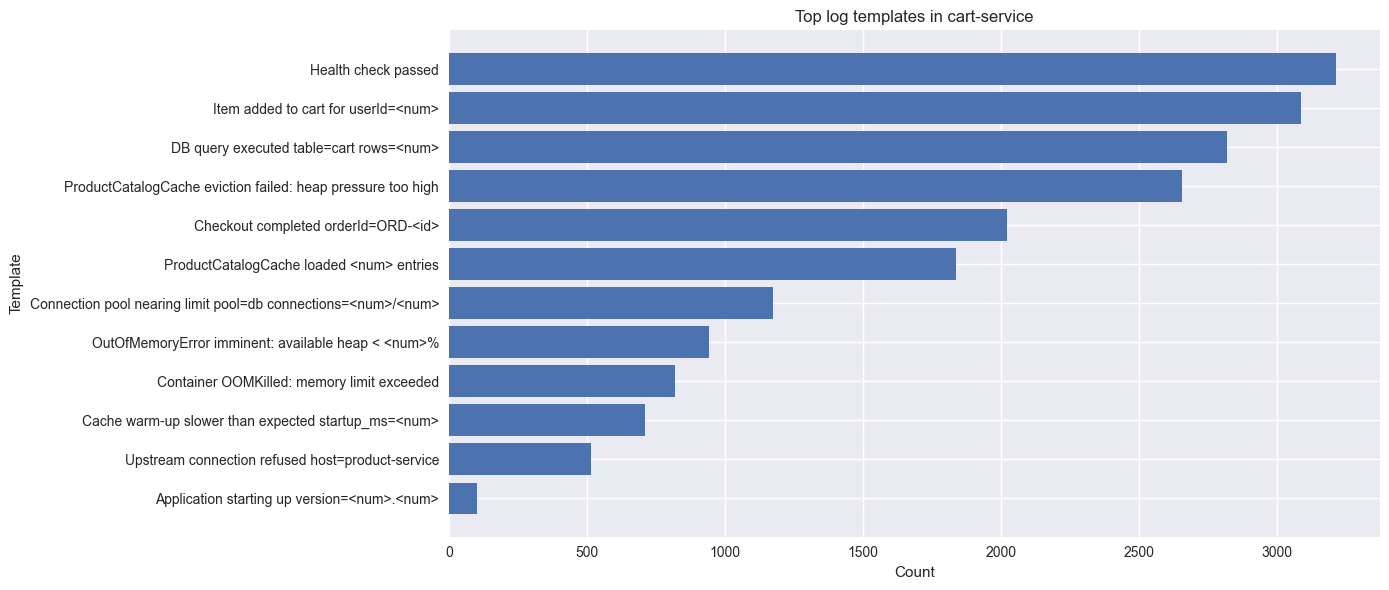

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
top = pd.DataFrame(cart_counter.most_common(12), columns=['template', 'count'])
ax.barh(top['template'][::-1], top['count'][::-1])
ax.set_title('Top log templates in cart-service')
ax.set_xlabel('Count')
ax.set_ylabel('Template')
fig.tight_layout()
fig.savefig(ART / 'log_templates_top12.png', dpi=150, bbox_inches='tight')
plt.show()


KeyError: 'memory_usage_bytes'

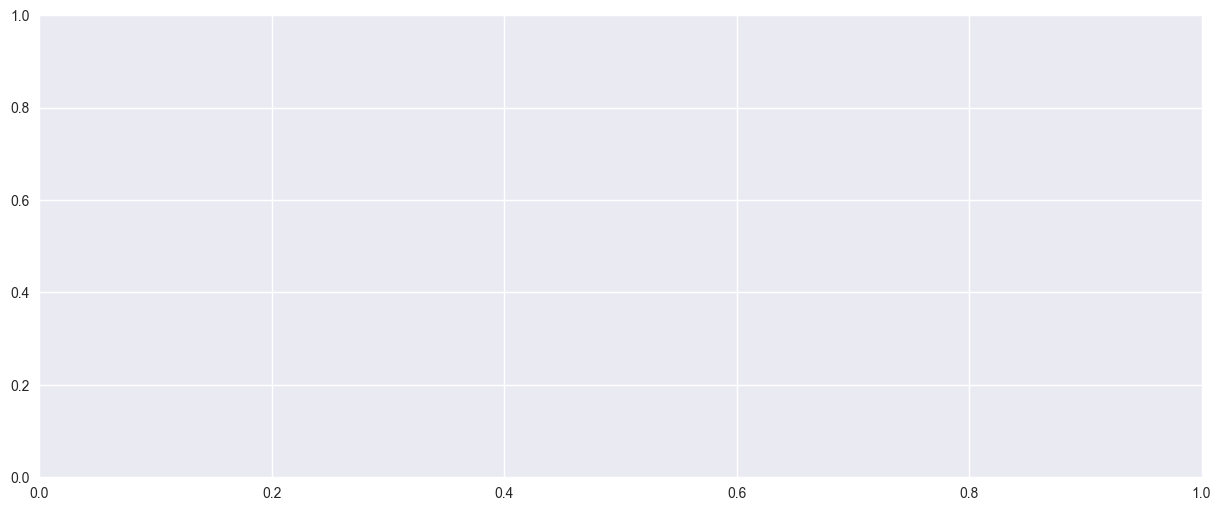

In [ ]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(cart['timestamp'], cart['memory_usage_bytes'] / (1024**3), color='steelblue', linewidth=1.0, label='Memory usage (GB)')
ax.axvline(pd.Timestamp('2026-06-01T06:32:33Z'), color='purple', linestyle='--', linewidth=1.1, label='First cache eviction failed')
ax.axvline(pd.Timestamp('2026-06-01T19:59:00Z'), color='red', linestyle='--', linewidth=1.1, label='OOM imminent')
ax.axvline(pd.Timestamp('2026-06-01T19:59:02Z'), color='black', linestyle='--', linewidth=1.1, label='OOMKilled')
ax.set_title('Memory usage with incident markers')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Memory (GB)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(ART / 'chart_03_memory_annotated.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
timeline = cart_window[['window_30m', 'warn_error_count']].copy()
timeline = timeline.merge(order_window[['window_30m', 'timeout_refused_count']], on='window_30m', how='left')
timeline['timeout_refused_count'] = timeline['timeout_refused_count'].fillna(0)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(timeline['window_30m'], timeline['warn_error_count'], color='tomato', linewidth=1.8, label='cart-service WARN+ERROR+FATAL')
ax.plot(timeline['window_30m'], timeline['timeout_refused_count'], color='steelblue', linewidth=1.5, label='order-service timeout/refused')
ax.axvline(ALERT_TIME, color='red', linestyle='--', linewidth=1.2, label='Alert fired')
ax.axvline(pd.Timestamp('2026-06-01T06:32:33Z'), color='purple', linestyle='--', linewidth=1.0, label='First cache eviction failed')
ax.axvline(pd.Timestamp('2026-06-01T19:59:00Z'), color='darkred', linestyle='--', linewidth=1.0, label='OOM imminent')
ax.axvline(pd.Timestamp('2026-06-01T19:59:02Z'), color='black', linestyle='--', linewidth=1.0, label='OOMKilled')
ax.set_title('Incident timeline: cart-service symptom, alert, and downstream impact')
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Event count per 30-minute window')
ax.legend(loc='upper left', ncols=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(ART / 'chart_07_incident_timeline.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
trace_counts = trace_summary.head(10).reset_index()
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(trace_counts['trace_id'][::-1], trace_counts['event_count'][::-1], color='teal')
ax.set_title('Top trace_id activity in cart-service warnings/errors')
ax.set_xlabel('Event count')
ax.set_ylabel('trace_id')
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(ART / 'chart_06_trace_activity.png', dpi=150, bbox_inches='tight')
plt.show()


K?t lu?n ch?nh:
- Template `heap pressure too high` xu?t hi?n s?m.
- `WARN+ERROR+FATAL` t?ng trong silent window tr??c alert.
- `trace_id` h?u ?ch ?? soi chu?i event trong t?ng service, nh?ng data kh?ng c? trace chung xuy?n service.
- `OOMKilled` v? `Application starting up` cho th?y restart loop.
- `chart_07_incident_timeline.png` l? bi?u ?? ch?nh ?? tr?nh b?y WHEN/WHERE/WHAT.
